# Principal Component Analysis of S&P 500 Stocks

This notebook explores how stocks move together and how those patterns differ across company sizes. It downloads one year of closing prices, groups the listed S&P 500 stocks into market-cap thirds, and applies principal component analysis (PCA) separately to each group.

## Workflow

1. **Download prices.** Call `get_SP500()` from `data.py`, which uses `yfinance` and concurrent threads to retrieve each ticker's closing-price history once. Combine the results in `df`, with trading dates as rows and tickers as columns, then plot the prices without a legend.
2. **Group stocks by market cap.** Call `split_by_market_cap(sp500_df)` from `data.py`. It retrieves Yahoo Finance's reported market cap, trying `fast_info` first and `info` as a fallback. Sort the tickers from smallest to largest and split them into three nearly equal groups: `small_cap_tickers`, `medium_cap_tickers`, and `large_cap_tickers`. These are relative thirds within the listed universe, rather than fixed dollar categories. Missing market caps stop the grouping step.
3. **Build group DataFrames.** The split function selects the corresponding columns from the full price DataFrame and returns `small_cap_df`, `medium_cap_df`, and `large_cap_df`, reusing the downloaded prices.
4. **Calculate returns and covariance.** For each group, use `pct_change(fill_method=None)` to calculate daily fractional returns. Keep only dates with returns for every stock in that group, then calculate its return covariance matrix.
5. **Run PCA.** `Covariance_PCA` decomposes each covariance matrix into eigenvalues and eigenvectors, ordered by decreasing variance. It plots each stock's loadings on the first two principal components and the percentage of variance explained by every component. The notebook also prints the variance percentages for the first five components in each group.

## Reading the results

- **PC1** captures the direction of greatest variation in the group's returns; **PC2** captures the greatest remaining variation along a perpendicular direction.
- **Loadings** are the stocks' coefficients in each component. Stocks with similar loadings contribute similarly to those directions of variation.
- **Variance explained** measures each component's share of total return variance. A large PC1 share suggests much of the group's variation can be summarized by one common direction.

Run the cells from top to bottom using the **DataScience** environment. Market-cap membership reflects values retrieved when the notebook runs. PCA uses return covariance without standardizing each stock's volatility, so stocks with higher return variance can have greater influence. The common-date filter may leave a short sample for stocks with limited history, and PCA describes variation rather than predicting future returns.


In [ ]:
# Imports
import matplotlib.pyplot as plt
from HelperFunctions.data import get_SP500, split_by_market_cap
from HelperFunctions.sci_functions import Covariance_PCA


In [ ]:
# Download the full S&P 500 closing-price DataFrame.
sp500_df = get_SP500()
df = sp500_df

sp500_df.plot(kind='line', legend=False)
plt.show()


In [ ]:
# Split prices into relative market-cap thirds, smallest to largest.
small_cap_df, medium_cap_df, large_cap_df = split_by_market_cap(sp500_df)

# Ticker arrays are available from each group's columns.
small_cap_tickers = small_cap_df.columns.to_numpy()
medium_cap_tickers = medium_cap_df.columns.to_numpy()
large_cap_tickers = large_cap_df.columns.to_numpy()

for label, group in zip(
    ['small cap', 'medium cap', 'large cap'],
    [small_cap_df, medium_cap_df, large_cap_df],
):
    print(f'{label}: {group.shape[1]} tickers')


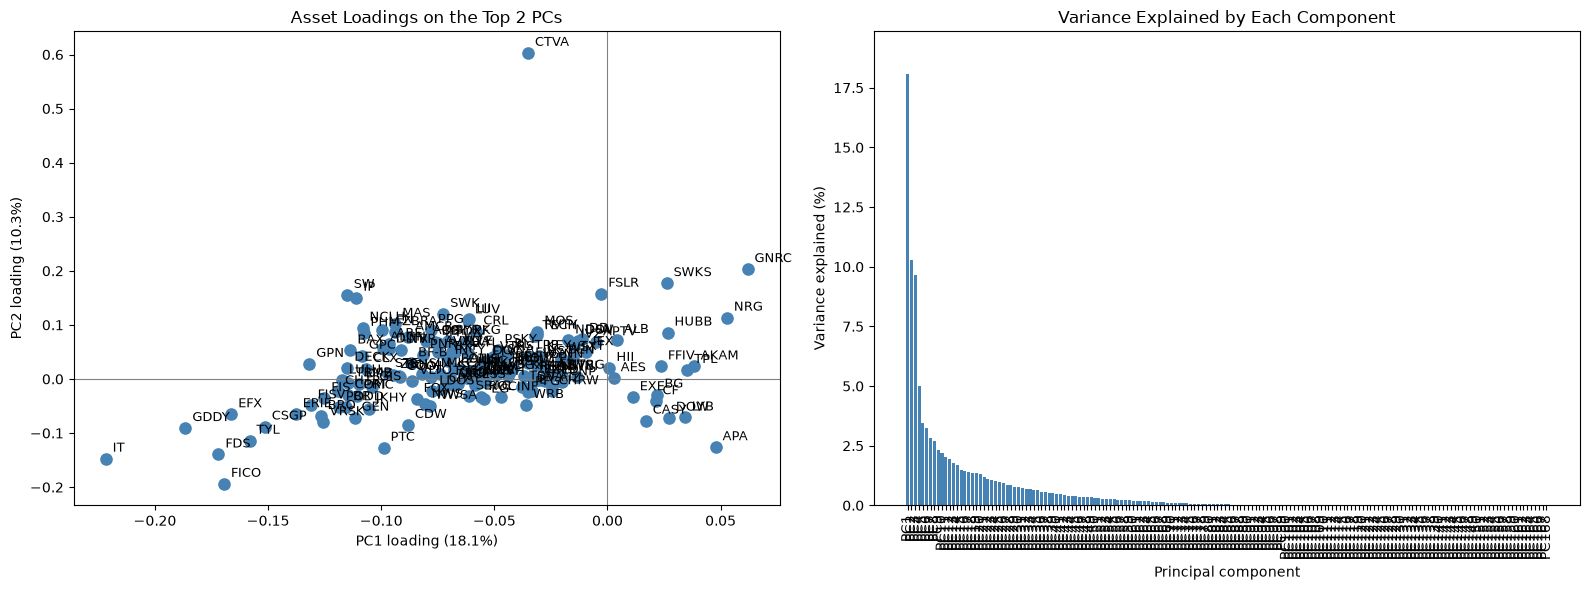

Market Cap Group: small cap
Variance Explained Of First 5 Components: [18.05772386 10.28366467  9.64688402  5.00950932  3.44393601]




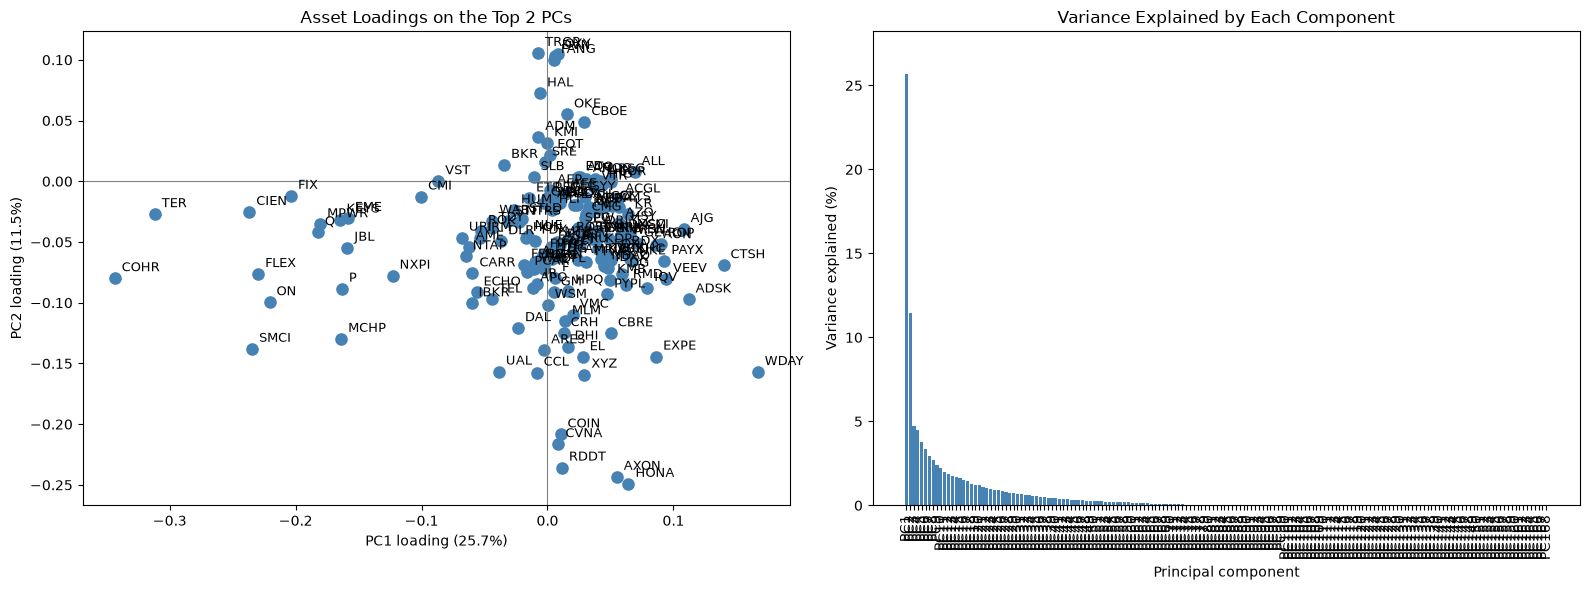

Market Cap Group: medium cap
Variance Explained Of First 5 Components: [25.65451735 11.45135754  4.71016562  4.49096722  3.79999235]




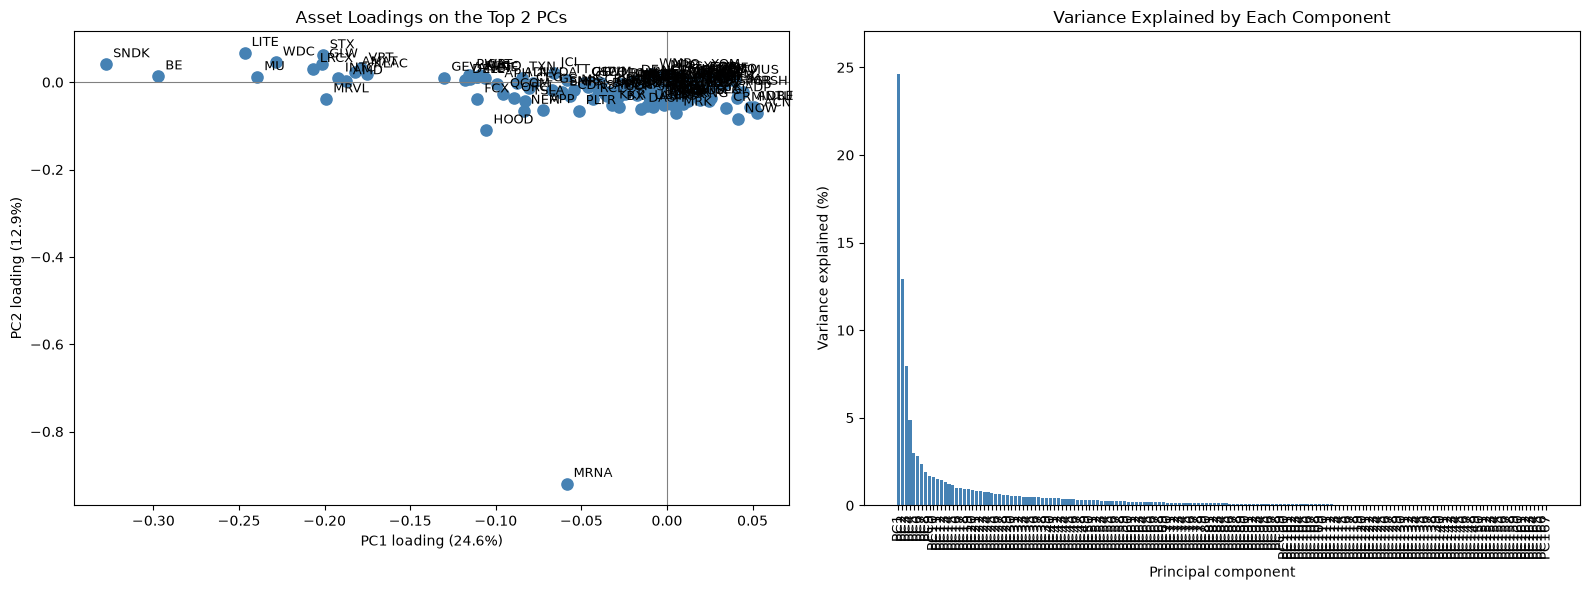

Market Cap Group: large cap
Variance Explained Of First 5 Components: [24.59806801 12.93188579  7.94231826  4.88772532  3.01312263]




In [10]:
for i in range(3):
    group_label = ['small cap', 'medium cap', 'large cap'][i]
    group_df = [small_cap_df, medium_cap_df, large_cap_df][i]

    returns = group_df.pct_change(fill_method=None)

    # Every stock must have a return for the same date.
    returns_common = returns.dropna(axis=0, how='any')

    covMatrix = returns_common.cov()

    eigenvalues, eigenvectors, variance_explained = Covariance_PCA(
        covMatrix,
        n_components=2  # Change to 2 for a 2D plot
    )
    print(f"Market Cap Group: {group_label}")
    #print("Eigenvalues:", eigenvalues)
    #print("Eigenvectors:\n", eigenvectors)
    print("Variance Explained Of First 5 Components:", variance_explained[0:5])  # Show variance explained for the first two components
    print("\n")
